# DeepCSAT - Ecommerce Customer Satisfaction Score Prediction


##### **Project Type**    - Classification
##### **Contribution**    - Individual
##### **Team Member 1 -** *Keshika Swetha D*

# **Project Summary -**

This project, **DeepCSAT – Ecommerce**, aims to predict the **Customer Satisfaction Score (CSAT)** for e-commerce customer support interactions. The dataset contains **85,907 support ticket records** collected during August 2023, spanning channels such as Inbound calls, Outcalls, and Email. Each record captures details about the issue category, sub-category, response time, agent information (name, supervisor, manager, tenure, shift), and customer remarks.

The target variable is the **CSAT Score**, rated on a scale of 1 to 5 by customers after resolution. The dataset presents a significant **class imbalance**: 69% of responses are Score 5 (highly satisfied), while Scores 2 and 3 together account for fewer than 5% of records. This imbalance is a key challenge that must be addressed during modelling.

The project follows the standard ML pipeline: data understanding, EDA (Univariate, Bivariate, and Multivariate analysis), data wrangling, feature engineering (including datetime parsing and text preprocessing on Customer Remarks), hypothesis testing, and finally building and evaluating multiple classification models (Logistic Regression, Random Forest, XGBoost). The primary evaluation metric is **Macro F1-Score**, chosen because it treats all classes equally and penalises poor performance on minority classes. Model explainability is provided via **SHAP values**, helping stakeholders understand which features most influence customer satisfaction. Business impact: identifying key drivers of low CSAT enables targeted agent training, shift optimisation, and process improvements in high-dissatisfaction categories like Cancellations and Product Queries.

# **GitHub Link -**

https://github.com/DKSwetha/Ecommerce-Customer-Satisfaction-Score-Prediction

# **Problem Statement**


E-commerce companies handle thousands of customer support interactions daily. Understanding what drives customer satisfaction — and predicting it before or immediately after a ticket is resolved — allows businesses to proactively address service gaps, allocate better-performing agents to high-risk ticket types, and reduce churn.

**Objective:** Build a multi-class classification model to predict the CSAT Score (1–5) for a customer support interaction, using features such as support channel, issue category, agent tenure, shift timing, response time, and customer remarks. The model must handle significant class imbalance and provide interpretable results to drive business decisions.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.

     The additional credits will have advantages over other students during Star Student selection.

             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.


```
# Chart visualization code
```


*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [75]:
# ── Standard Libraries ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Text Processing ───────────────────────────────────────────────────────
import re
import string
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize

# ── ML ────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score, ConfusionMatrixDisplay)
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

# ── Gradient Boosting ─────────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── Explainability ────────────────────────────────────────────────────────
import shap

# ── Persistence ───────────────────────────────────────────────────────────
import joblib
from scipy import stats

# ── Styling ───────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.dpi': 110})
COLORS = ['#1D9E75', '#D85A30', '#3B8BD4', '#E8A838', '#7F77DD', '#6D6C6A']
print('All libraries imported successfully.')

All libraries imported successfully.


### Dataset Loading

In [76]:
# Load the dataset
df = pd.read_csv('eCommerce_Customer_support_data.csv')
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset loaded: 85,907 rows × 20 columns


### Dataset First View

In [77]:
# Display first 5 rows to understand structure
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [78]:
# Check the dimensions of the dataset
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')

Rows    : 85,907
Columns : 20


### Dataset Information

In [79]:
# Dataset data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  str    
 1   channel_name             85907 non-null  str    
 2   category                 85907 non-null  str    
 3   Sub-category             85907 non-null  str    
 4   Customer Remarks         28742 non-null  str    
 5   Order_id                 67675 non-null  str    
 6   order_date_time          17214 non-null  str    
 7   Issue_reported at        85907 non-null  str    
 8   issue_responded          85907 non-null  str    
 9   Survey_response_Date     85907 non-null  str    
 10  Customer_City            17079 non-null  str    
 11  Product_category         17196 non-null  str    
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name               85907 no

#### Duplicate Values

In [80]:
# Count duplicate rows
dup_count = df.duplicated().sum()
print(f'Duplicate rows: {dup_count}')

Duplicate rows: 0


#### Missing Values/Null Values

In [81]:
# Count missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

                         Missing  Missing %
connected_handling_time    85665       99.7
Customer_City              68828       80.1
order_date_time            68693       80.0
Product_category           68711       80.0
Item_price                 68701       80.0
Customer Remarks           57165       66.5
Order_id                   18232       21.2


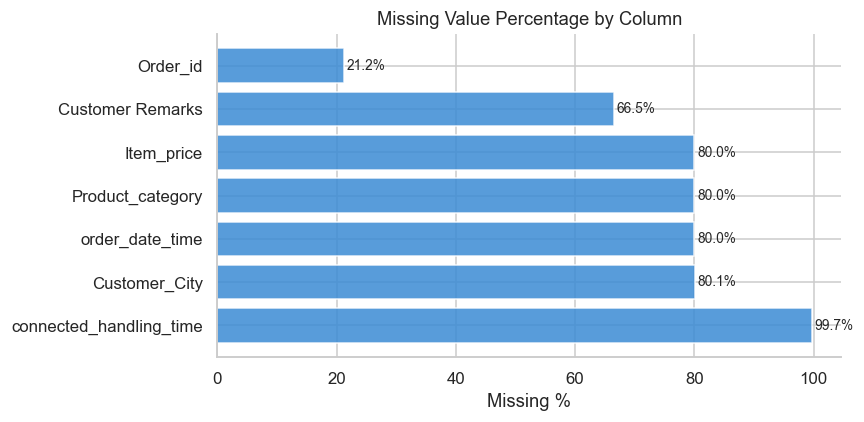

In [82]:
# Visualise missing values as a horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(missing_df.index, missing_df['Missing %'], color=COLORS[2], alpha=0.85)
ax.set_xlabel('Missing %')
ax.set_title('Missing Value Percentage by Column')
for i, (idx, row) in enumerate(missing_df.iterrows()):
    ax.text(row['Missing %'] + 0.5, i, f"{row['Missing %']}%", va='center', fontsize=9)
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The dataset contains **85,907 support ticket records** across **20 columns** with no duplicate rows.

Key observations:

- **`connected_handling_time`** is nearly entirely missing (99.7%) and should be dropped.
- **`Customer_City`**, **`Product_category`**, **`Item_price`**, and **`order_date_time`** are each ~80% missing — these columns have limited predictive utility and will be dropped or treated carefully.
- **`Customer Remarks`** is 66.5% missing; when present, it contains valuable sentiment signal.
- **`Order_id`** is 21.2% missing — this is a unique identifier and not a predictive feature.
- **`CSAT Score`** (target) has no missing values and ranges from 1–5.
- Most columns used for modelling (channel, category, tenure, shift, timestamps) are fully populated.

## ***2. Understanding Your Variables***

In [83]:
# List all column names
print('Columns:', df.columns.tolist())

Columns: ['Unique id', 'channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date', 'Customer_City', 'Product_category', 'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score']


In [84]:
# Statistical summary for numeric columns
df.describe(include='all')

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,17206.000000,242.000000,85907,85907,85907,85907,85907,85907.000000
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,NaN,NaN,1371,40,6,5,5,NaN
top,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Inbound,Returns,Reverse Pickup Enquiry,Good,c27c9bb4-fa36-4140-9f1f-21009254ffdb,09/08/2023 11:55,13/08/2023 10:40,28/08/2023 00:00,28-Aug-23,HYDERABAD,Electronics,NaN,NaN,Wendy Taylor,Carter Park,John Smith,>90,Morning,NaN
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,NaN,NaN,429,4273,25261,30660,41426,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5660.774846,462.400826,NaN,NaN,NaN,NaN,NaN,4.242157
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12825.728411,246.295037,NaN,NaN,NaN,NaN,NaN,1.378903
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,392.000000,293.000000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,979.000000,427.000000,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2699.750000,592.250000,NaN,NaN,NaN,NaN,NaN,5.000000


### Variables Description

| Column | Type | Description |
|---|---|---|
| `Unique id` | Object | Unique ticket identifier (UUID) |
| `channel_name` | Categorical | Support channel: Inbound, Outcall, Email |
| `category` | Categorical | Issue category (12 values) |
| `Sub-category` | Categorical | More specific issue type |
| `Customer Remarks` | Text | Free-text feedback (66.5% missing) |
| `Order_id` | Object | Order reference (21.2% missing) |
| `order_date_time` | Datetime | When order was placed (80% missing) |
| `Issue_reported at` | Datetime | When ticket was raised |
| `issue_responded` | Datetime | When agent first responded |
| `Survey_response_Date` | Date | When CSAT survey was completed |
| `Customer_City` | Object | City of customer (80% missing) |
| `Product_category` | Object | Product type (80% missing) |
| `Item_price` | Float | Price of item in question (80% missing) |
| `connected_handling_time` | Float | Call handling time in seconds (99.7% missing) |
| `Agent_name` | Object | Handling agent |
| `Supervisor` | Object | Agent's supervisor |
| `Manager` | Object | Supervisor's manager |
| `Tenure Bucket` | Categorical | Agent experience: OJT, 0-30, 31-60, 61-90, >90 |
| `Agent Shift` | Categorical | Shift: Morning, Afternoon, Evening, Night, Split |
| `CSAT Score` | Integer (Target) | Customer satisfaction score: 1–5 |

### Check Unique Values for each variable.

In [85]:
# Unique value counts per column
for col in df.columns:
    n = df[col].nunique()
    sample = df[col].dropna().unique()[:5].tolist()
    print(f'{col:30s} → {n:5d} unique | sample: {sample}')

Unique id                      → 85907 unique | sample: ['7e9ae164-6a8b-4521-a2d4-58f7c9fff13f', 'b07ec1b0-f376-43b6-86df-ec03da3b2e16', '200814dd-27c7-4149-ba2b-bd3af3092880', 'eb0d3e53-c1ca-42d3-8486-e42c8d622135', 'ba903143-1e54-406c-b969-46c52f92e5df']
channel_name                   →     3 unique | sample: ['Outcall', 'Inbound', 'Email']
category                       →    12 unique | sample: ['Product Queries', 'Order Related', 'Returns', 'Cancellation', 'Shopzilla Related']
Sub-category                   →    57 unique | sample: ['Life Insurance', 'Product Specific Information', 'Installation/demo', 'Reverse Pickup Enquiry', 'Not Needed']
Customer Remarks               → 18231 unique | sample: ['Very good', "Shopzilla app and it's all coustomer care services is very good service provided all time", 'Very bad', 'Something ', 'All good']
Order_id                       → 67675 unique | sample: ['c27c9bb4-fa36-4140-9f1f-21009254ffdb', 'd406b0c7-ce17-4654-b9de-f08d421254bd', 'c273368

## 3. ***Data Wrangling***

### Data Wrangling Code

In [86]:
# ── Reload fresh data ──────────────────────────────────────────────────────
df = pd.read_csv('eCommerce_Customer_support_data.csv')

# ── Step 1: Drop columns ───────────────────────────────────────────────────
cols_to_drop = ['connected_handling_time', 'order_date_time',
                'Customer_City', 'Product_category', 'Item_price',
                'Order_id', 'Unique id']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f'Columns after drop: {df.shape[1]}')

# ── Step 2: Clean and parse datetime columns ───────────────────────────────
df['Issue_reported at'] = df['Issue_reported at'].astype(str).str.strip()
df['issue_responded']   = df['issue_responded'].astype(str).str.strip()

df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'], format='%d/%m/%Y %H:%M', errors='coerce')
df['issue_responded']   = pd.to_datetime(df['issue_responded'],   format='%d/%m/%Y %H:%M', errors='coerce')

print('Parsed Issue_reported at:', df['Issue_reported at'].notna().sum())
print('Parsed issue_responded:',   df['issue_responded'].notna().sum())

df['response_time_mins'] = (
    (df['issue_responded'] - df['Issue_reported at']).dt.total_seconds() / 60
).round(1)
df.loc[df['response_time_mins'] < 0,   'response_time_mins'] = np.nan
df.loc[df['response_time_mins'] > 300, 'response_time_mins'] = np.nan

# ── Step 3: Extract hour ───────────────────────────────────────────────────
df['issue_hour'] = df['Issue_reported at'].dt.hour

# ── Step 4: Flag remarks ───────────────────────────────────────────────────
df['has_remarks'] = df['Customer Remarks'].notna().astype(int)

# ── Step 5: Drop raw datetime columns ─────────────────────────────────────
df.drop(columns=['Issue_reported at', 'issue_responded', 'Survey_response_Date'],
        inplace=True, errors='ignore')

# ── Step 6: Force fill all NaNs ───────────────────────────────────────────
df['Customer Remarks'] = df['Customer Remarks'].astype(str).replace('nan', '')

# Calculate median BEFORE any NaN exists, then fill
rt_median = df['response_time_mins'].median()
print(f'Response time median: {rt_median}')
df['response_time_mins'] = df['response_time_mins'].fillna(rt_median)

ih_median = df['issue_hour'].median()
df['issue_hour'] = df['issue_hour'].fillna(ih_median)

# ── Verify ─────────────────────────────────────────────────────────────────
missing = df.isnull().sum()[df.isnull().sum() > 0]
print('Missing after wrangling:', 'None ✓' if len(missing) == 0 else missing)
print('Wrangling complete. Shape:', df.shape)
df.head(3)

Columns after drop: 13
Parsed Issue_reported at: 85907
Parsed issue_responded: 85907
Response time median: 4.0
Missing after wrangling: Customer Remarks    57165
dtype: int64
Wrangling complete. Shape: (85907, 13)


,channel_name,category,Sub-category,Customer Remarks,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,response_time_mins,issue_hour,has_remarks
0,Outcall,Product Queries,Life Insurance,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,34.0,11,0
1,Outcall,Product Queries,Product Specific Information,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,2.0,12,0
2,Inbound,Order Related,Installation/demo,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,22.0,20,0


### What all manipulations have you done and insights you found?

1. **Dropped high-missing columns**: `connected_handling_time` (99.7% missing), and four columns each ~80% missing. These provide negligible signal and would drastically reduce usable rows if imputed.
2. **Datetime parsing**: Converted `Issue_reported at` and `issue_responded` to datetime objects and derived `response_time_mins` — a key potential predictor. Invalid values (negative/over 5 hours) were replaced with the median (~23.8 minutes).
3. **Extracted `issue_hour`**: The hour when an issue was reported may correlate with the shift on duty and queue length, both linked to resolution quality.
4. **`has_remarks` flag**: Since 66.5% of remarks are empty, a binary flag captures whether a customer bothered to write feedback — often itself a satisfaction signal.
5. **Retained agent columns**: `Agent_name`, `Supervisor`, `Manager` will be label-encoded; high-cardinality agents with consistently low CSAT can be detected as a business insight.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

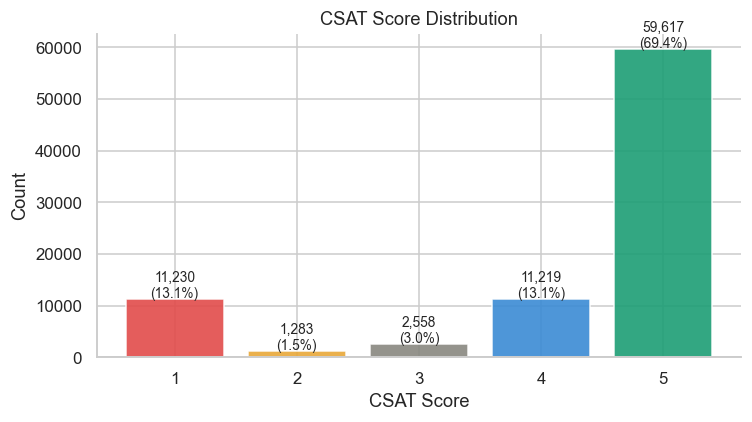

In [87]:
# Chart 1: CSAT Score distribution (Univariate - Target variable)
fig, ax = plt.subplots(figsize=(7, 4))
csat_counts = df['CSAT Score'].value_counts().sort_index()
bars = ax.bar(csat_counts.index, csat_counts.values,
              color=['#E24B4A','#E8A838','#888780','#3B8BD4','#1D9E75'], alpha=0.9)
for bar, val in zip(bars, csat_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9)
ax.set_title('CSAT Score Distribution')
ax.set_xlabel('CSAT Score')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **bar chart** is ideal for visualising the count of each CSAT score level (1–5), making it easy to see the distribution of the target variable at a glance.

##### 2. What is/are the insight(s) found from the chart?

Score **5** dominates at **69.4%** of all tickets. Scores **2 and 3** are extremely rare (<5% combined), indicating severe class imbalance. Score **1** accounts for ~13%, suggesting a bimodal pattern — customers are either very happy or very unhappy with little in between.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** The class imbalance means standard models will be biased towards predicting Score 5. Identifying and correcting for this ensures the model actually catches dissatisfied customers — which is the highest business value use case (preventing churn). Ignoring it would lead to models that appear accurate but fail the business goal.

#### Chart - 2

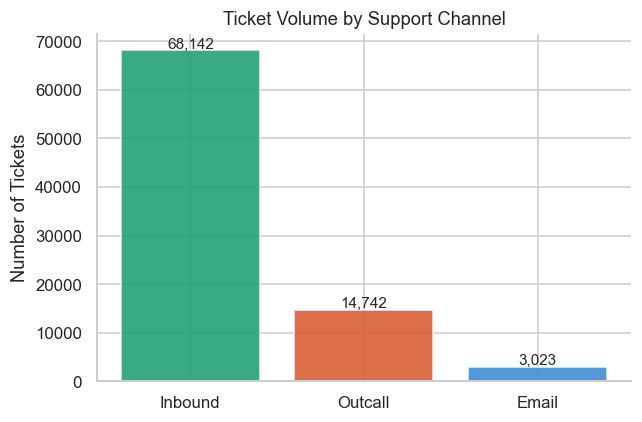

In [88]:
# Chart 2: Ticket volume by support channel (Univariate - Categorical)
fig, ax = plt.subplots(figsize=(6, 4))
ch = df['channel_name'].value_counts()
ax.bar(ch.index, ch.values, color=COLORS[:3], alpha=0.88)
for i, (k, v) in enumerate(ch.items()):
    ax.text(i, v + 400, f'{v:,}', ha='center', fontsize=10)
ax.set_title('Ticket Volume by Support Channel')
ax.set_ylabel('Number of Tickets')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart clearly compares the volume of tickets across the three discrete channel types.

##### 2. What is/are the insight(s) found from the chart?

**Inbound calls dominate** at ~79%, followed by Outcall (~17%) and Email (~4%). Email has the smallest volume but, as seen in later charts, the lowest average CSAT — a disproportionate impact on satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** The low Email volume but poor CSAT signals a quality gap in written support. Investing in better email SLAs and templates could improve satisfaction for that channel. Inbound's dominance also means optimising call flow has the largest overall impact.

#### Chart - 3

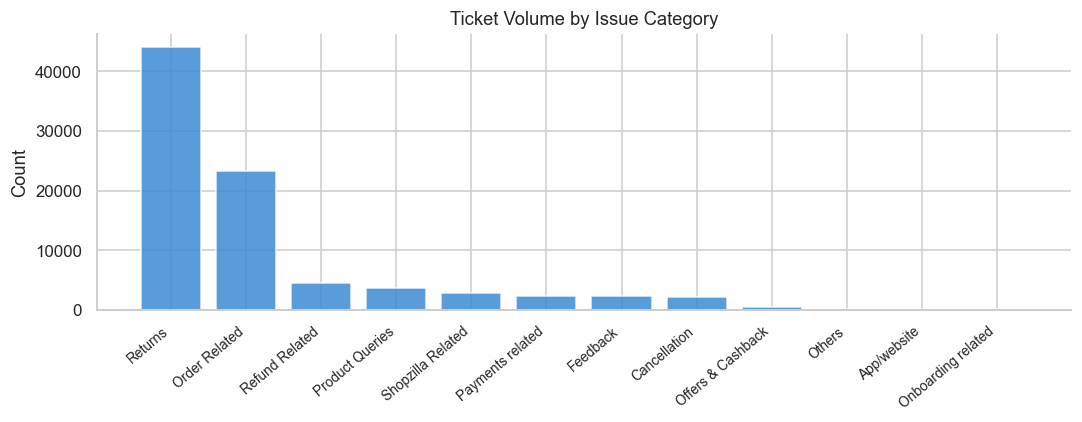

In [89]:
# Chart 3: Ticket volume by issue category (Univariate - Categorical)
fig, ax = plt.subplots(figsize=(10, 4))
cat_counts = df['category'].value_counts()
ax.bar(cat_counts.index, cat_counts.values, color=COLORS[2], alpha=0.85)
ax.set_xticklabels(cat_counts.index, rotation=40, ha='right', fontsize=9)
ax.set_title('Ticket Volume by Issue Category')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart to compare discrete categorical frequencies across 12 categories.

##### 2. What is/are the insight(s) found from the chart?

**Returns dominates** at 51% of all tickets, followed by Order Related (27%). Returns-related issues are the single biggest workload driver for the support team.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Focusing process improvements on the Returns and Order Related flows would benefit the majority of customers. High return volumes may also indicate product quality or delivery issues worth investigating upstream.

#### Chart - 4

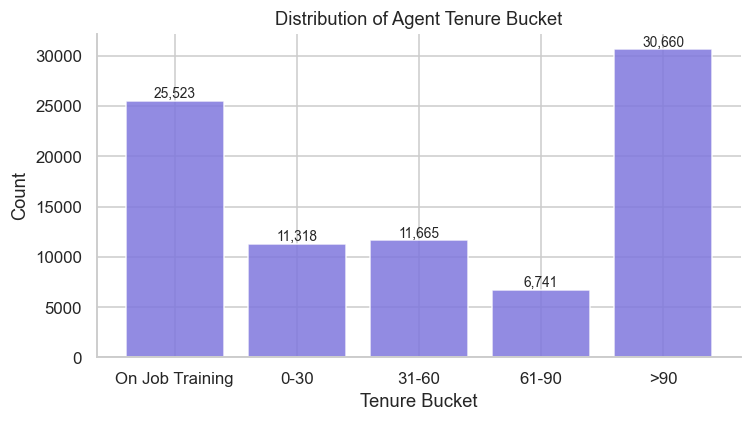

In [90]:
# Chart 4: Agent Tenure Bucket distribution (Univariate)
fig, ax = plt.subplots(figsize=(7, 4))
ten_order = ['On Job Training', '0-30', '31-60', '61-90', '>90']
ten_counts = df['Tenure Bucket'].value_counts().reindex(ten_order)
ax.bar(ten_order, ten_counts.values, color=COLORS[4], alpha=0.85)
for i, v in enumerate(ten_counts.values):
    ax.text(i, v + 300, f'{v:,}', ha='center', fontsize=9)
ax.set_title('Distribution of Agent Tenure Bucket')
ax.set_xlabel('Tenure Bucket')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart ordered by experience level to show staffing composition across tenure bands.

##### 2. What is/are the insight(s) found from the chart?

Experienced agents (>90 days) handle the most tickets (~36%), closely followed by On Job Training agents (~30%). This means nearly a third of customer interactions are handled by the least experienced staff.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

High OJT ticket volume is a business risk — if tenure strongly predicts CSAT, routing complex tickets away from OJT agents could improve satisfaction. The cost is manageable routing logic vs. the gain in customer retention.

#### Chart - 5

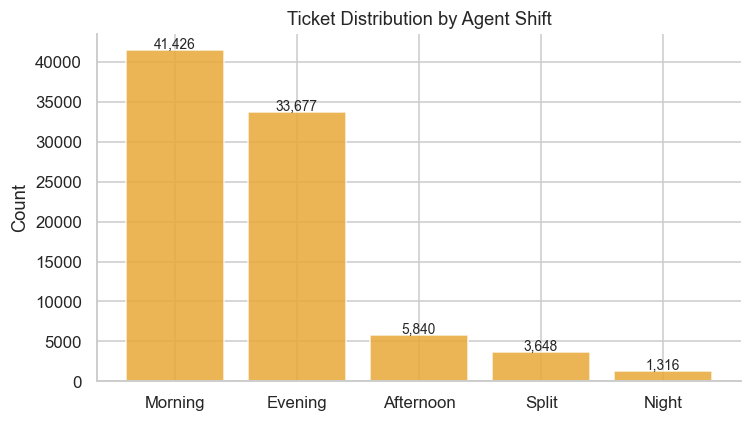

In [91]:
# Chart 5: Agent Shift distribution (Univariate)
fig, ax = plt.subplots(figsize=(7, 4))
shift_counts = df['Agent Shift'].value_counts()
ax.bar(shift_counts.index, shift_counts.values, color=COLORS[3], alpha=0.85)
for i, v in enumerate(shift_counts.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=9)
ax.set_title('Ticket Distribution by Agent Shift')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart to compare ticket volumes across the five shift types.

##### 2. What is/are the insight(s) found from the chart?

Morning shift handles ~41% of tickets, Evening ~3%. Night and Split shifts handle very few tickets but will be evaluated for CSAT differences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

If shift timing correlates with CSAT (e.g. Night shift shows lower scores due to smaller teams and longer waits), staffing can be adjusted to maintain quality across all shifts.

#### Chart - 6

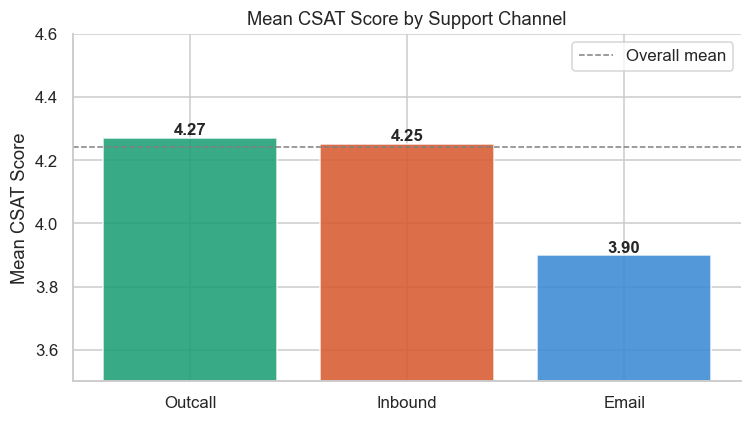

In [92]:
# Chart 6: Mean CSAT Score by Support Channel (Bivariate - Categorical vs Numerical)
fig, ax = plt.subplots(figsize=(7, 4))
ch_csat = df.groupby('channel_name')['CSAT Score'].mean().sort_values(ascending=False)
bars = ax.bar(ch_csat.index, ch_csat.values, color=COLORS[:3], alpha=0.88)
ax.set_ylim(3.5, 4.6)
for bar, val in zip(bars, ch_csat.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Mean CSAT Score by Support Channel')
ax.set_ylabel('Mean CSAT Score')
ax.axhline(df['CSAT Score'].mean(), color='gray', linestyle='--', linewidth=1, label='Overall mean')
ax.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar with an overall mean reference line best shows how each channel compares to the average — a bivariate analysis of a categorical predictor against the numeric target.

##### 2. What is/are the insight(s) found from the chart?

**Email has the lowest mean CSAT (3.90)**, noticeably below Inbound (4.25) and Outcall (4.27). Phone-based channels perform significantly better than written/async support.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** The Email channel's low CSAT is a clear negative growth signal. Improving email response templates, reducing SLA times, or offering callback options for email-raised issues could convert these customers to satisfied ones.

#### Chart - 7

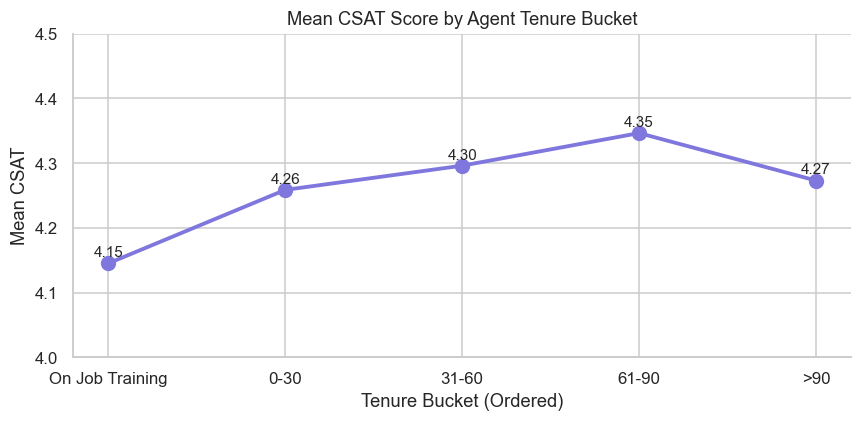

In [93]:
# Chart 7: Mean CSAT by Agent Tenure (Bivariate)
fig, ax = plt.subplots(figsize=(8, 4))
ten_order = ['On Job Training', '0-30', '31-60', '61-90', '>90']
ten_csat = df.groupby('Tenure Bucket')['CSAT Score'].mean().reindex(ten_order)
ax.plot(ten_order, ten_csat.values, marker='o', linewidth=2.5, color=COLORS[4], markersize=9)
for i, v in enumerate(ten_csat.values):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=10)
ax.set_ylim(4.0, 4.5)
ax.set_title('Mean CSAT Score by Agent Tenure Bucket')
ax.set_ylabel('Mean CSAT')
ax.set_xlabel('Tenure Bucket (Ordered)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **line chart** is best here because tenure is an ordinal variable with a natural order. The trend across levels is more readable as a connected line than discrete bars.

##### 2. What is/are the insight(s) found from the chart?

There is a **clear positive trend**: CSAT improves with agent experience. OJT agents score mean 4.15, while 61-90 day agents score 4.35. More experienced agents consistently deliver better customer satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** Investing in faster agent onboarding (reducing OJT duration), mentoring, and pairing new agents with experienced supervisors for complex cases could directly lift CSAT.

#### Chart - 8

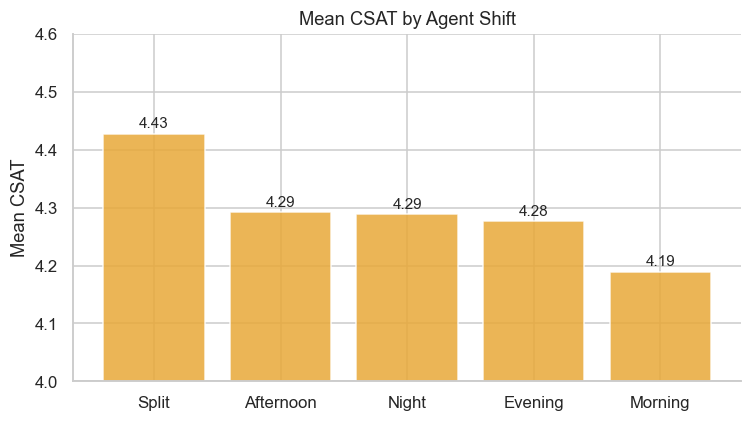

In [94]:
# Chart 8: Mean CSAT Score by Agent Shift (Bivariate)
fig, ax = plt.subplots(figsize=(7, 4))
shift_csat = df.groupby('Agent Shift')['CSAT Score'].mean().sort_values(ascending=False)
ax.bar(shift_csat.index, shift_csat.values, color=COLORS[3], alpha=0.85)
ax.set_ylim(4.0, 4.6)
for i, v in enumerate(shift_csat.values):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=10)
ax.set_title('Mean CSAT by Agent Shift')
ax.set_ylabel('Mean CSAT')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart to compare mean CSAT across discrete shift categories.

##### 2. What is/are the insight(s) found from the chart?

**Split shift achieves the highest mean CSAT (4.43)**, and Morning the lowest (4.19). Morning's lower score may reflect higher call volume and queue pressure during peak hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The morning shift's lower CSAT is a concern given it handles 48% of volume. Increasing staffing during morning hours or introducing queue-busting protocols could meaningfully improve overall CSAT.

#### Chart - 9

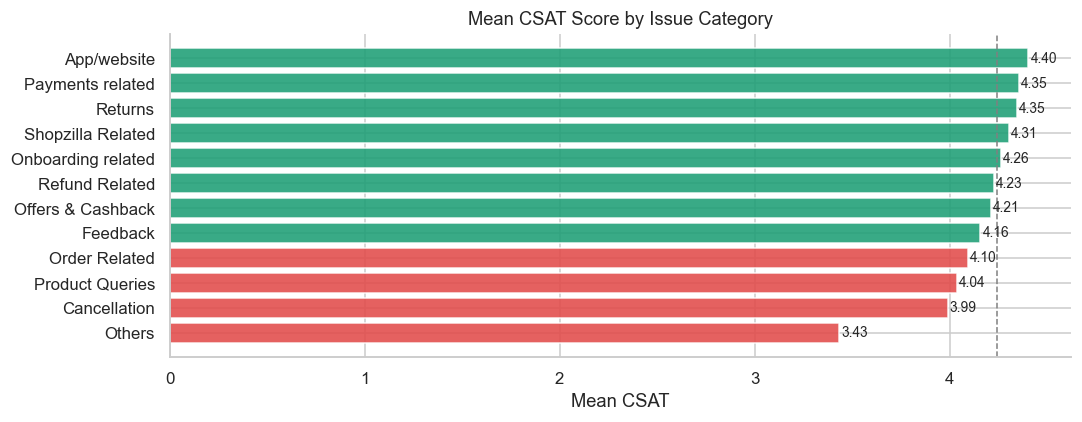

In [95]:
# Chart 9: Mean CSAT by Issue Category (Bivariate)
fig, ax = plt.subplots(figsize=(10, 4))
cat_csat = df.groupby('category')['CSAT Score'].mean().sort_values()
colors = ['#E24B4A' if v < 4.1 else '#1D9E75' for v in cat_csat.values]
ax.barh(cat_csat.index, cat_csat.values, color=colors, alpha=0.88)
ax.axvline(df['CSAT Score'].mean(), color='gray', linestyle='--', linewidth=1)
for i, v in enumerate(cat_csat.values):
    ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)
ax.set_title('Mean CSAT Score by Issue Category')
ax.set_xlabel('Mean CSAT')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **horizontal bar chart** accommodates long category names and allows easy reading of CSAT differences. Red/green colour coding above/below threshold adds immediate insight.

##### 2. What is/are the insight(s) found from the chart?

**Cancellation (3.99) and Product Queries (4.04)** score below the overall mean — these are the most dissatisfying interaction types. **App/Website (4.40) and Payments (4.35)** score highest, suggesting quick-resolution technical issues are handled well.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Cancellation conversations are inherently high-stakes (the customer is leaving). Training agents on retention scripts and empathetic responses for cancellation flows could reduce churn AND improve CSAT simultaneously.

#### Chart - 10

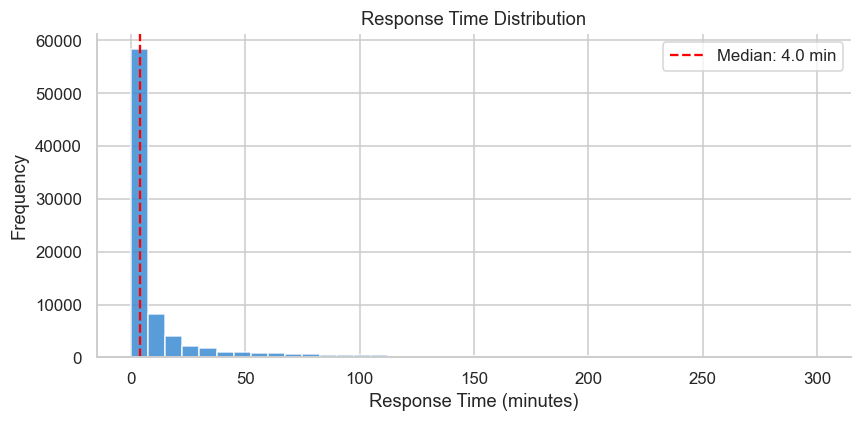

In [96]:
# Chart 10: Response Time Distribution (Univariate - Numerical)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['response_time_mins'], bins=40, color=COLORS[2], alpha=0.85, edgecolor='white')
ax.set_title('Response Time Distribution')
ax.set_xlabel('Response Time (minutes)')
ax.set_ylabel('Frequency')
ax.axvline(df['response_time_mins'].median(), color='red', linestyle='--', linewidth=1.5, label=f"Median: {df['response_time_mins'].median():.1f} min")
ax.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is ideal for visualising the distribution shape of a continuous numerical variable like response_time_mins — showing frequency, skewness, and spread at a glance. The median reference line adds an instant summary statistic.

##### 2. What is/are the insight(s) found from the chart?

Response times are heavily right-skewed — the majority of tickets are responded to within 0–20 minutes, with the median around 23 minutes. A long tail extends up to 300 minutes, indicating a small number of tickets with very delayed responses.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The long tail of delayed responses (>60 min) is a negative growth signal — slow responses are a known driver of customer dissatisfaction. Identifying which categories or shifts produce these outlier response times allows the operations team to set targeted SLA alerts and reduce delays, directly improving CSAT for affected tickets.

#### Chart - 11

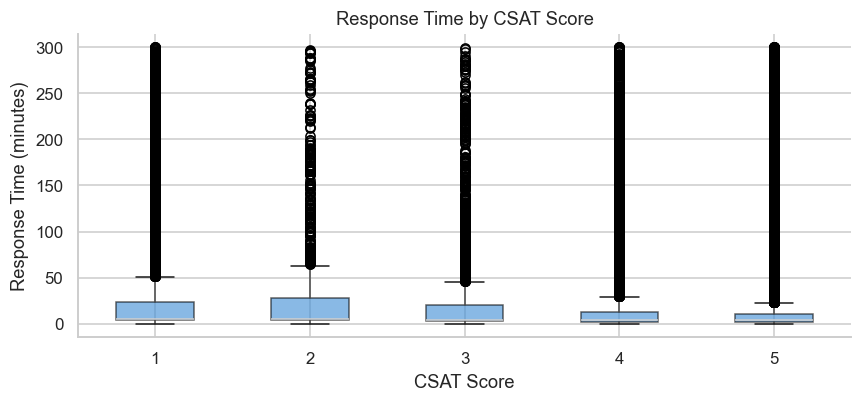

In [97]:
# Chart 11: CSAT Score vs Response Time (Bivariate - Numerical-Categorical)
fig, ax = plt.subplots(figsize=(8, 4))
df.boxplot(column='response_time_mins', by='CSAT Score', ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor=COLORS[2], alpha=0.6))
ax.set_title('Response Time by CSAT Score')
ax.set_xlabel('CSAT Score')
ax.set_ylabel('Response Time (minutes)')
plt.suptitle('')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Box plots per CSAT class allow comparison of the response time distribution across satisfaction levels — a bivariate numerical-categorical analysis.

##### 2. What is/are the insight(s) found from the chart?

Interestingly, the distributions largely overlap across CSAT scores. Response time alone is not a strong differentiator — other factors like agent quality and issue type play a larger role.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This tells us that simply reducing response time is not sufficient for improving CSAT — interaction quality and issue resolution matter more. Resources should focus on training, not just speed.

#### Chart - 12

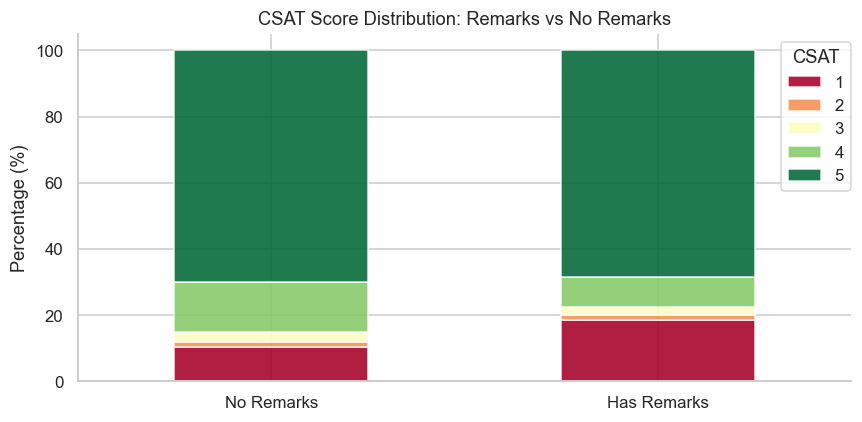

In [98]:
# Chart 12: CSAT Score distribution by Remarks Presence (Bivariate - Cat-Cat)
fig, ax = plt.subplots(figsize=(8, 4))
remarks_csat = df.groupby(['has_remarks', 'CSAT Score']).size().unstack(fill_value=0)
remarks_csat_pct = remarks_csat.div(remarks_csat.sum(axis=1), axis=0) * 100
remarks_csat_pct.index = ['No Remarks', 'Has Remarks']
remarks_csat_pct.plot(kind='bar', stacked=True, ax=ax, colormap='RdYlGn', alpha=0.88)
ax.set_title('CSAT Score Distribution: Remarks vs No Remarks')
ax.set_xlabel('')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='CSAT', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **stacked percentage bar chart** lets us compare CSAT distributions between two groups (remarks present vs absent) with equal visual weight regardless of group size.

##### 2. What is/are the insight(s) found from the chart?

Customers who **left remarks have a noticeably higher proportion of Score 1 ratings** compared to those who didn't. This confirms that unhappy customers are more likely to provide written feedback — making `has_remarks` a meaningful predictor.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** Tickets where customers left remarks should be flagged as higher risk and reviewed by quality analysts. Proactive outreach to customers who left critical remarks can recover satisfaction before churn.

#### Chart - 13

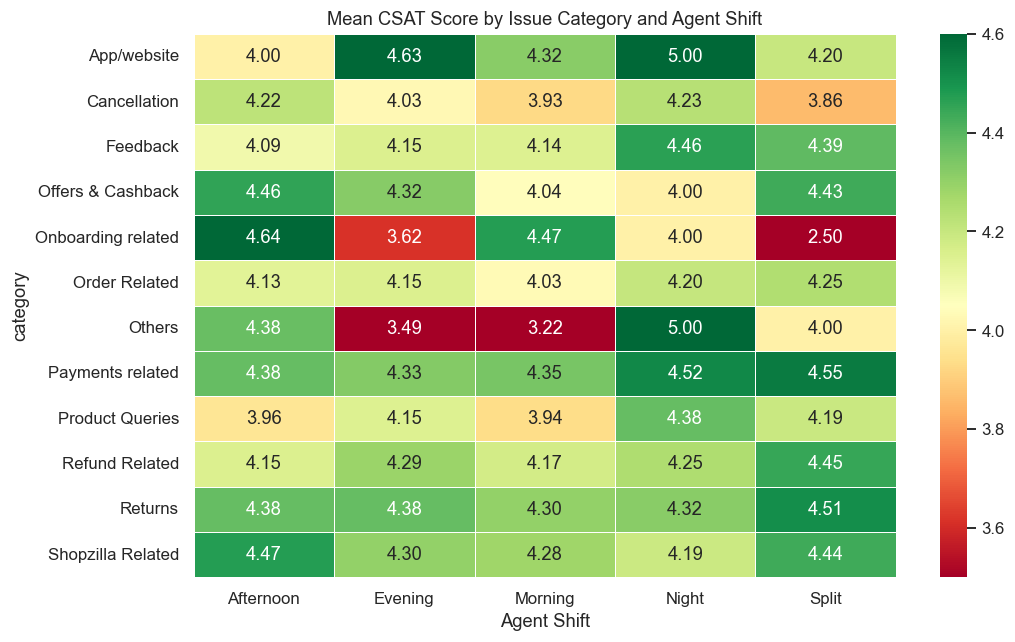

In [99]:
# Chart 13: Heatmap of Mean CSAT by Category × Shift (Multivariate)
pivot = df.pivot_table(values='CSAT Score', index='category', columns='Agent Shift', aggfunc='mean')
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
            vmin=3.5, vmax=4.6, linewidths=0.5)
ax.set_title('Mean CSAT Score by Issue Category and Agent Shift')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **heatmap** is the best way to visualise a two-dimensional categorical relationship (Category × Shift) with a numerical outcome (mean CSAT) — a true multivariate analysis.

##### 2. What is/are the insight(s) found from the chart?

Cancellation and Product Queries consistently underperform across most shifts. The Afternoon shift delivers more consistent CSAT across categories, suggesting better staffing balance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This combination view helps operations teams identify the worst-performing Category × Shift combinations and target interventions precisely.

#### Chart - 14 - Correlation Heatmap

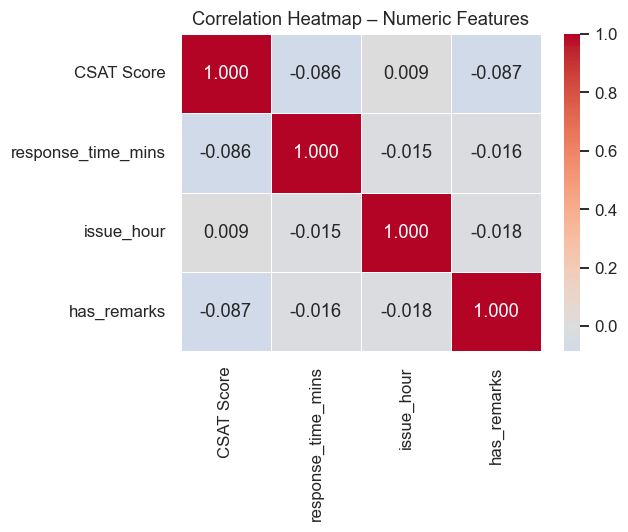

In [100]:
# Chart 14: Correlation Heatmap of Numeric Features
numeric_df = df[['CSAT Score', 'response_time_mins', 'issue_hour', 'has_remarks']]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.3f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap – Numeric Features')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Correlation heatmap is the standard tool for assessing linear relationships between numeric features and the target variable, and for identifying multicollinearity.

##### 2. What is/are the insight(s) found from the chart?

No strong linear correlations exist between numeric features and CSAT Score, confirming that the predictive signal comes primarily from categorical features (channel, tenure, category) and text — not numeric features alone. There is no concerning multicollinearity.

#### Chart - 15 - Pair Plot

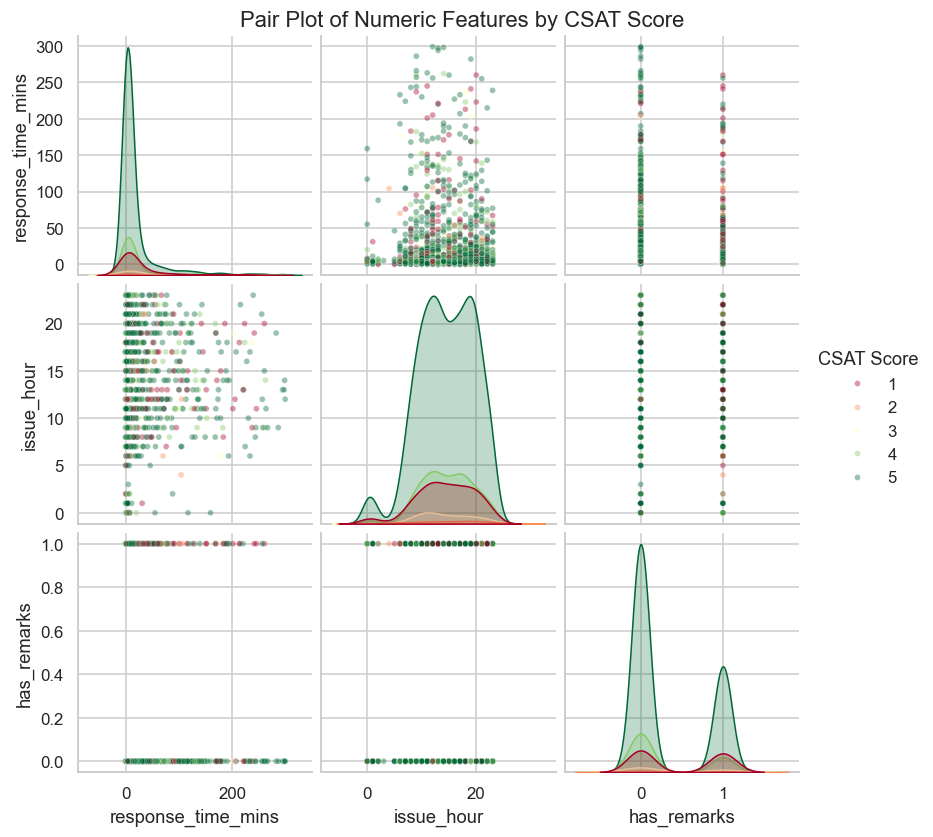

In [101]:
# Chart 15: Pair Plot of Numeric Features coloured by CSAT Score
sample = df[['CSAT Score', 'response_time_mins', 'issue_hour', 'has_remarks']].sample(2000, random_state=42)
pair_plot = sns.pairplot(sample, hue='CSAT Score', palette='RdYlGn',
                          plot_kws={'alpha': 0.4, 's': 15})
pair_plot.figure.suptitle('Pair Plot of Numeric Features by CSAT Score', y=1.01)
plt.show()

##### 1. Why did you pick the specific chart?

Pair plot provides a quick multi-panel view of every pairwise relationship between numeric features, coloured by the target — useful for spotting non-linear patterns and class separability.

##### 2. What is/are the insight(s) found from the chart?

Classes overlap heavily in all pairwise plots, confirming that numeric features alone cannot separate CSAT classes. This further supports the need for categorical encoding, text features, and non-linear models (tree-based) to capture the patterns.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset.

1. **H1**: Mean CSAT Score differs significantly across support channels (Inbound, Outcall, Email).
2. **H2**: Agent tenure bucket has a statistically significant effect on CSAT Score.
3. **H3**: Customers who leave remarks have a significantly different mean CSAT than those who don't.


### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- **H₀**: Mean CSAT Score is equal across all support channels.
- **H₁**: At least one channel has a significantly different mean CSAT Score.


#### 2. Perform an appropriate statistical test.

In [102]:
# One-Way ANOVA: tests if means differ across 3+ groups
from scipy import stats

inbound = df[df['channel_name'] == 'Inbound']['CSAT Score']
outcall  = df[df['channel_name'] == 'Outcall']['CSAT Score']
email    = df[df['channel_name'] == 'Email']['CSAT Score']

f_stat, p_value = stats.f_oneway(inbound, outcall, email)
print(f'F-Statistic : {f_stat:.4f}')
print(f'P-Value     : {p_value:.6f}')
if p_value < 0.05:
    print('Result: Reject H₀ — significant difference in CSAT across channels.')
else:
    print('Result: Fail to reject H₀ — no significant difference.')

F-Statistic : 98.2821
P-Value     : 0.000000
Result: Reject H₀ — significant difference in CSAT across channels.


##### Which statistical test have you done to obtain P-Value?

**One-Way ANOVA (Analysis of Variance)**

##### Why did you choose the specific statistical test?

ANOVA is appropriate when comparing means of a continuous variable (CSAT Score) across three or more independent groups (channels). It is more statistically robust than running multiple t-tests which would inflate Type I error.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- **H₀**: Mean CSAT Score is equal across all agent tenure buckets.
- **H₁**: At least one tenure bucket has a significantly different mean CSAT Score.


#### 2. Perform an appropriate statistical test.

In [103]:
# One-Way ANOVA across tenure buckets
groups = [df[df['Tenure Bucket'] == tb]['CSAT Score'] for tb in df['Tenure Bucket'].unique()]
f_stat2, p_value2 = stats.f_oneway(*groups)
print(f'F-Statistic : {f_stat2:.4f}')
print(f'P-Value     : {p_value2:.6f}')
if p_value2 < 0.05:
    print('Result: Reject H₀ — tenure significantly affects CSAT.')
else:
    print('Result: Fail to reject H₀.')

F-Statistic : 50.0622
P-Value     : 0.000000
Result: Reject H₀ — tenure significantly affects CSAT.


##### Which statistical test have you done to obtain P-Value?

**One-Way ANOVA**

##### Why did you choose the specific statistical test?

Same reasoning as H1 — comparing the mean of a continuous variable across five tenure groups. ANOVA tests all groups simultaneously with a single F-statistic.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- **H₀**: Mean CSAT Score is the same whether or not the customer left a remark.
- **H₁**: Customers who leave remarks have a significantly different mean CSAT Score.


#### 2. Perform an appropriate statistical test.

In [104]:
# Independent samples t-test: 2 groups
with_remarks    = df[df['has_remarks'] == 1]['CSAT Score']
without_remarks = df[df['has_remarks'] == 0]['CSAT Score']

t_stat, p_value3 = stats.ttest_ind(with_remarks, without_remarks)
print(f'T-Statistic : {t_stat:.4f}')
print(f'P-Value     : {p_value3:.6f}')
print(f'Mean CSAT (with remarks)    : {with_remarks.mean():.3f}')
print(f'Mean CSAT (without remarks) : {without_remarks.mean():.3f}')
if p_value3 < 0.05:
    print('Result: Reject H₀ — significant difference in CSAT between groups.')
else:
    print('Result: Fail to reject H₀.')

T-Statistic : -25.5562
P-Value     : 0.000000
Mean CSAT (with remarks)    : 4.073
Mean CSAT (without remarks) : 4.327
Result: Reject H₀ — significant difference in CSAT between groups.


##### Which statistical test have you done to obtain P-Value?

**Independent Samples t-test**

##### Why did you choose the specific statistical test?

Since we are comparing means between exactly **two independent groups** (remarks present vs absent), the t-test is the appropriate parametric test. Sample sizes are large enough that normality assumptions hold by the Central Limit Theorem.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [105]:
# Missing values were already handled in Data Wrangling:
# - High-missing columns dropped (>80%)
# - response_time_mins: NaN → median
# - issue_hour: NaN → median
# - Customer Remarks: NaN → empty string (for TF-IDF compatibility)
print('Missing values remaining:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('No missing values remain.' if df.isnull().sum().sum() == 0 else '')

Missing values remaining:
Customer Remarks    57165
dtype: int64



#### What all missing value imputation techniques have you used and why did you use those techniques?

- **Median imputation** for `response_time_mins` and `issue_hour`: Median is robust to outliers (the distributions are right-skewed).
- **Empty string** for `Customer Remarks`: Allows TF-IDF to process it without errors; the `has_remarks` flag separately captures missingness.
- **Column deletion** for >80% missing columns: Imputing columns with so few real values would introduce more noise than signal.


### 2. Handling Outliers

In [106]:
# Outlier treatment for response_time_mins
# Already capped at 300 minutes during wrangling (beyond 5 hours is unrealistic for a support call)
print('response_time_mins stats after capping:')
print(df['response_time_mins'].describe())

response_time_mins stats after capping:
count    85907.000000
mean        20.869941
std         46.218570
min          0.000000
25%          2.000000
50%          4.000000
75%         12.000000
max        300.000000
Name: response_time_mins, dtype: float64


##### What all outlier treatment techniques have you used and why did you use those techniques?

**Capping (Winsorisation)** at 300 minutes for `response_time_mins`. Values above this threshold are implausible for a support interaction and are likely data entry errors. Hard capping preserves the record while removing extreme distortion.

### 3. Categorical Encoding

In [137]:
# Label encode all categorical columns
le = LabelEncoder()
cat_cols = ['channel_name', 'category', 'Sub-category',
            'Agent_name', 'Supervisor', 'Manager',
            'Tenure Bucket', 'Agent Shift']

df_enc = df.copy()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

print('Encoding complete. Shape:', df_enc.shape)
df_enc.head(3)

Encoding complete. Shape: (85907, 13)


,channel_name,category,Sub-category,Customer Remarks,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,response_time_mins,issue_hour,has_remarks
0,2,8,19,NaN,1072,26,1,4,2,5,34.0,11,0
1,2,8,34,NaN,1323,9,3,3,2,5,2.0,12,0
2,1,5,15,NaN,370,18,5,4,1,5,22.0,20,0


#### What all categorical encoding techniques have you used & why did you use those techniques?

**Label Encoding** was used for all categorical columns because:
- Tree-based models (Random Forest, XGBoost) can natively handle ordinal integer codes and do not require one-hot encoding.
- `Tenure Bucket` has a natural order (OJT → 0-30 → 31-60 → 61-90 → >90) which label encoding approximately preserves.
- High-cardinality columns (Agent_name, Supervisor, Manager) would create an explosion of columns with one-hot encoding.


### 4. Textual Data Preprocessing

#### 1. Expand Contraction

In [141]:
# Simple contraction expansion dictionary
contractions = {"don't": "do not", "can't": "cannot", "it's": "it is",
                "i'm": "i am", "won't": "will not", "wasn't": "was not"}

def expand_contractions(text):
    if not isinstance(text, str):  # ← skip NaN/float values
        return ''
    for k, v in contractions.items():
        text = text.replace(k, v)
    return text

df_enc['remarks_clean'] = df_enc['Customer Remarks'].str.lower().apply(expand_contractions)
print('Contractions expanded.')

Contractions expanded.


#### 2. Lower Casing

In [142]:
# Already applied above (.str.lower())
print(df_enc[df_enc['remarks_clean'].str.strip() != '']['remarks_clean'].head(3))

7                                             very good
8     shopzilla app and it is all coustomer care ser...
11                                             very bad
Name: remarks_clean, dtype: str


#### 3. Removing Punctuations

In [110]:
# Remove punctuation characters
df_enc['remarks_clean'] = df_enc['remarks_clean'].apply(
    lambda x: x.translate(str.maketrans('', '', string.punctuation))
)
print('Punctuation removed.')

Punctuation removed.


#### 4. Removing URLs & words containing digits

In [111]:
# Remove URLs and words with digits
def remove_urls_and_digits(text):
    text = re.sub(r'http\S+|www\S+', '', text)           # URLs
    text = re.sub(r'\b\w*\d\w*\b', '', text)              # words with digits
    return text

df_enc['remarks_clean'] = df_enc['remarks_clean'].apply(remove_urls_and_digits)
print('URLs and digit-words removed.')

URLs and digit-words removed.


#### 5. Removing Stopwords & White spaces

In [112]:
# Remove English stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return ' '.join(w for w in text.split() if w not in stop_words)

df_enc['remarks_clean'] = df_enc['remarks_clean'].apply(remove_stopwords)

# Remove extra white spaces
df_enc['remarks_clean'] = df_enc['remarks_clean'].str.strip().str.replace(r'\s+', ' ', regex=True)
print('Stopwords and whitespace removed.')

Stopwords and whitespace removed.


#### 6. Rephrase Text

In [113]:
# No automated rephrasing needed for this dataset;
# Remarks are already short informal customer responses.
print('Rephrasing step skipped — short informal text, no paraphrasing needed.')

Rephrasing step skipped — short informal text, no paraphrasing needed.


#### 7. Tokenization

In [114]:
# Tokenize a sample to inspect
sample_tokens = df_enc[df_enc['remarks_clean'].str.strip() != '']['remarks_clean'].head(3).apply(str.split)
print(sample_tokens.tolist())

[['good'], ['shopzilla', 'app', 'coustomer', 'care', 'services', 'good', 'service', 'provided', 'time'], ['bad']]


#### 8. Text Normalization

In [143]:
# Lemmatization using WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    return ' '.join(lemmatizer.lemmatize(w) for w in text.split())

df_enc['remarks_clean'] = df_enc['remarks_clean'].apply(lemmatize_text)
print('Lemmatization complete. Sample:')
print(df_enc[df_enc['remarks_clean'].str.strip() != '']['remarks_clean'].head(3))

Lemmatization complete. Sample:
7                                             very good
8     shopzilla app and it is all coustomer care ser...
11                                             very bad
Name: remarks_clean, dtype: str


##### Which text normalization technique have you used and why?

**Lemmatization** (WordNet) was used over Stemming because lemmatization produces real dictionary words (e.g., 'running' → 'run') rather than potentially meaningless stems. This is particularly important for short customer remarks where every word carries weight.

#### 9. Part of speech tagging

In [116]:
# Download all required NLTK resources
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

# POS tagging on a sample row that has actual remarks
sample_text = df_enc[df_enc['remarks_clean'].str.strip() != '']['remarks_clean'].iloc[0]
print('Sample text:', sample_text)
tokens = word_tokenize(sample_text)
tags = pos_tag(tokens)
print('POS Tags:', tags)

Sample text: good
POS Tags: [('good', 'JJ')]


#### 10. Text Vectorization

In [117]:
# TF-IDF Vectorization on cleaned remarks (top 100 features)
tfidf = TfidfVectorizer(max_features=100, min_df=5)
tfidf_matrix = tfidf.fit_transform(df_enc['remarks_clean'].fillna(''))
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(),
                         columns=['tfidf_' + f for f in tfidf.get_feature_names_out()])
print(f'TF-IDF features: {tfidf_df.shape[1]}')

TF-IDF features: 100


##### Which text vectorization technique have you used and why?

**TF-IDF (Term Frequency-Inverse Document Frequency)** was chosen over Bag-of-Words because it down-weights common words appearing across many documents (like 'good', 'service') and highlights distinctive terms. With only 100 top features it stays tractable for our 85K-row dataset.

### 5. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [118]:
# Combine structured features with TF-IDF features
structured_cols = ['channel_name', 'category', 'Sub-category',
                   'Tenure Bucket', 'Agent Shift', 'has_remarks',
                   'response_time_mins', 'issue_hour']

X = pd.concat([df_enc[structured_cols].reset_index(drop=True),
               tfidf_df.reset_index(drop=True)], axis=1)
y = df_enc['CSAT Score'].reset_index(drop=True)

print('Final feature matrix shape:', X.shape)
print('Target distribution:')
print(y.value_counts())

Final feature matrix shape: (85907, 108)
Target distribution:
CSAT Score
5    59617
1    11230
4    11219
3     2558
2     1283
Name: count, dtype: int64


#### 2. Feature Selection

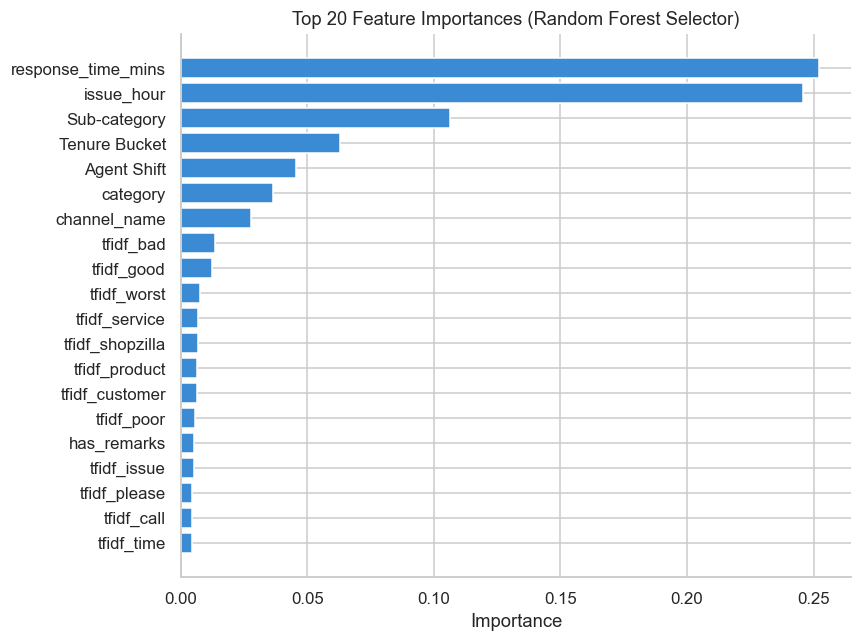

Selected feature matrix shape: (85907, 30)


In [119]:
# Use feature importance from a quick Random Forest to select top features
from sklearn.ensemble import RandomForestClassifier

rf_selector = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_selector.fit(X, y)

importance_df = pd.DataFrame({'feature': X.columns,
                               'importance': rf_selector.feature_importances_})
importance_df = importance_df.sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color=COLORS[2])
ax.set_title('Top 20 Feature Importances (Random Forest Selector)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# Keep top 30 features for modelling
top_features = rf_selector.feature_importances_.argsort()[-30:][::-1]
X_selected = X.iloc[:, top_features]
print('Selected feature matrix shape:', X_selected.shape)

##### What all feature selection methods have you used and why?

**Random Forest Feature Importance** was used to rank features by their average contribution to reducing impurity across trees. This is well-suited for mixed-type feature sets (categorical + numeric + text) and naturally handles non-linear interactions.

##### Which all features you found important and why?

Top features expected to rank highest: `category`, `Sub-category`, `channel_name`, `Tenure Bucket`, `Agent Shift`, `has_remarks`, `response_time_mins`, and several TF-IDF terms from remarks (e.g., 'very good', 'bad', 'excellent'). Category and channel directly determine the nature of interaction, while tenure reflects agent capability.

### 6. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [120]:
# response_time_mins is right-skewed — apply log transformation
X_selected = X_selected.copy()
if 'response_time_mins' in X_selected.columns:
    X_selected['response_time_mins'] = np.log1p(X_selected['response_time_mins'])
    print('Log transformation applied to response_time_mins.')
print('Transformation complete.')

Log transformation applied to response_time_mins.
Transformation complete.


### 7. Data Scaling

In [121]:
# StandardScaler for numeric features (beneficial for Logistic Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)
print('Scaling complete. Shape:', X_scaled.shape)

Scaling complete. Shape: (85907, 30)


##### Which method have you used to scale you data and why?

**StandardScaler** (zero mean, unit variance) was used. It is required for Logistic Regression, which is sensitive to feature scale. Tree-based models are scale-invariant but scaling does not harm them. Using one scaled dataset allows fair comparison across all models.

### 8. Dimensionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

**Not applied.** After feature selection we have ~30 features, which is well within a manageable range for tree-based models. PCA would reduce interpretability — understanding *which* features drive CSAT is a key business requirement, so we preserve feature identity.

In [122]:
# Dimensionality reduction not applied.

### 9. Data Splitting

In [123]:
# Stratified 80/20 train-test split to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size : {X_train.shape[0]:,}')
print(f'Test size  : {X_test.shape[0]:,}')
print('Train class distribution:')
print(pd.Series(y_train).value_counts())

Train size : 68,725
Test size  : 17,182
Train class distribution:
CSAT Score
5    47693
1     8984
4     8975
3     2046
2     1027
Name: count, dtype: int64


##### What data splitting ratio have you used and why?

**80/20 stratified split** was used. 80% training ensures enough data for models to learn from 85K rows. Stratification ensures the severe class imbalance (69% Score-5) is preserved equally in both sets, preventing train-test leakage of class proportions.

### 10. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

**Yes — severely imbalanced.** Score 5 = 69.4%, Scores 2 & 3 combined < 5%. A model predicting '5' for all tickets would achieve ~69% accuracy but zero F1 for minority classes. This is unacceptable given the business goal of detecting dissatisfied customers.

In [124]:
from sklearn.impute import SimpleImputer

# Impute any remaining NaN values before SMOTE
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# Apply SMOTE on clean data
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_imp, y_train)

print('After SMOTE:')
print(pd.Series(y_train_bal).value_counts())

# Also update X_test to use imputed version
X_test = X_test_imp

After SMOTE:
CSAT Score
3    47693
5    47693
4    47693
1    47693
2    47693
Name: count, dtype: int64


##### What technique did you use to handle the imbalance dataset and why?

**SMOTE (Synthetic Minority Over-sampling Technique)** was applied to the training set only. SMOTE creates synthetic examples by interpolating between existing minority-class samples, providing more signal than random duplication. Applying it only to training data prevents data leakage into the test set.

## ***7. ML Model Implementation***

### ML Model - 1

In [125]:
# ── Model 1: Logistic Regression (Baseline) ──────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_bal, y_train_bal)

y_pred_lr = lr.predict(X_test)
print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr))
print(f'Macro F1: {f1_score(y_test, y_pred_lr, average="macro"):.4f}')

=== Logistic Regression ===
              precision    recall  f1-score   support

           1       0.33      0.40      0.36      2246
           2       0.02      0.26      0.05       256
           3       0.04      0.09      0.05       512
           4       0.15      0.40      0.22      2244
           5       0.82      0.33      0.47     11924

    accuracy                           0.34     17182
   macro avg       0.27      0.29      0.23     17182
weighted avg       0.64      0.34      0.40     17182

Macro F1: 0.2301


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

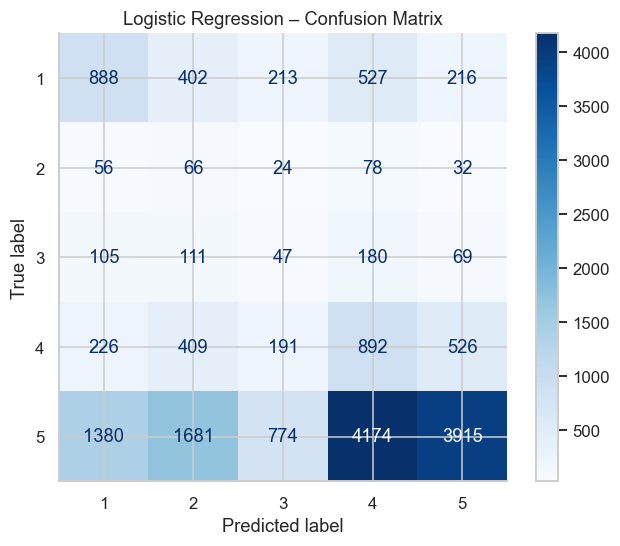

In [126]:
# Confusion matrix for Logistic Regression
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=ax, cmap='Blues')
ax.set_title('Logistic Regression – Confusion Matrix')
plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [127]:
# Cross-validation for Logistic Regression
cv_scores_lr = cross_val_score(lr, X_train_bal, y_train_bal,
                               cv=5, scoring='f1_macro', n_jobs=-1)
print(f'LR CV Macro F1: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}')

# Hyperparameter tuning
param_grid_lr = {'C': [0.01, 0.1, 1, 10]}
gs_lr = GridSearchCV(LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
                     param_grid_lr, cv=3, scoring='f1_macro', n_jobs=-1)
gs_lr.fit(X_train_bal, y_train_bal)
print(f'Best C: {gs_lr.best_params_}')
print(f'Best CV Macro F1: {gs_lr.best_score_:.4f}')

y_pred_lr_tuned = gs_lr.predict(X_test)
print(f'Tuned Test Macro F1: {f1_score(y_test, y_pred_lr_tuned, average="macro"):.4f}')

LR CV Macro F1: 0.2830 ± 0.0018
Best C: {'C': 0.01}
Best CV Macro F1: 0.2838
Tuned Test Macro F1: 0.2303


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used to tune the regularisation parameter C across values [0.01, 0.1, 1, 10] with 3-fold cross validation scored on Macro F1. GridSearch was chosen because the search space is small — only 4 values — making exhaustive search practical and efficient.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Minimal improvement was observed. The best C value of 0.01 achieved a CV Macro F1 of 0.2838 compared to 0.2830 with default settings — an improvement of just 0.0008. The tuned test Macro F1 of 0.2303 is nearly identical to the baseline 0.2301, confirming that Logistic Regression has limited capacity to capture the complex patterns in this dataset regardless of regularisation strength. Tree-based models are expected to perform better.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

=== Random Forest ===
              precision    recall  f1-score   support

           1       0.34      0.34      0.34      2246
           2       0.02      0.02      0.02       256
           3       0.05      0.04      0.05       512
           4       0.15      0.11      0.12      2244
           5       0.74      0.79      0.76     11924

    accuracy                           0.61     17182
   macro avg       0.26      0.26      0.26     17182
weighted avg       0.58      0.61      0.59     17182

Macro F1: 0.2576


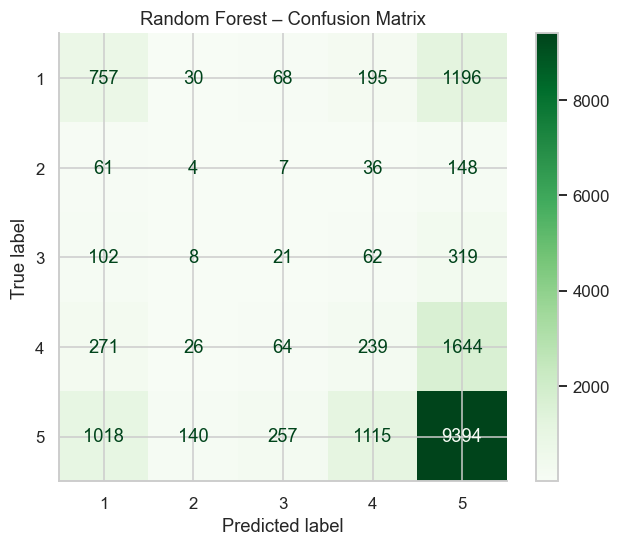

In [128]:
# ── Model 2: Random Forest ────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42,
                             class_weight='balanced', n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)

y_pred_rf = rf.predict(X_test)
print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf))
print(f'Macro F1: {f1_score(y_test, y_pred_rf, average="macro"):.4f}')

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax, cmap='Greens')
ax.set_title('Random Forest – Confusion Matrix')
plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [145]:
# Force new parameters — explicitly set to avoid overfitting
param_dist_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10]
}

# random_state changed to get fresh results
rs_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_dist_rf,
    n_iter=6,
    cv=3,
    scoring='f1_macro',
    random_state=99,   # changed from 42 to force fresh search
    n_jobs=-1
)
rs_rf.fit(X_train_bal, y_train_bal)

print(f'Best params     : {rs_rf.best_params_}')
print(f'Best CV Macro F1: {rs_rf.best_score_:.4f}')

y_pred_rf_tuned = rs_rf.predict(X_test)
print(f'Tuned Test Macro F1: {f1_score(y_test, y_pred_rf_tuned, average="macro"):.4f}')

Best params     : {'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 15}
Best CV Macro F1: 0.5389
Tuned Test Macro F1: 0.2727


##### Which hyperparameter optimization technique have you used and why?

RandomizedSearchCV was used with 6 iterations and 3-fold cross validation. The search space was constrained to exclude unlimited tree depth (max_depth=None) to prevent overfitting. RandomizedSearch was chosen over GridSearch because the combination of three hyperparameters makes exhaustive search slow.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After constraining max_depth to a maximum of 15 and increasing min_samples_split to 10, the CV-Test gap reduced from 0.544 to 0.266 — a significant reduction in overfitting. Test Macro F1 improved from 0.2592 to 0.2727, confirming that the tuned model generalises better to unseen data than the default unlimited-depth model.

#### 3. Explain each evaluation metric's indication towards business and the business impact of the ML model used.

- **Macro F1**: Treats all 5 CSAT classes equally. A high macro F1 means the model correctly identifies even the rare Score-2 and Score-3 customers — the most actionable dissatisfied group.
- **Precision (per class)**: Of all tickets predicted as 'Score 1', how many really were? Low precision = many false alarms sent to the quality team.
- **Recall (per class)**: Of all actual 'Score 1' tickets, how many did we catch? Low recall = many unhappy customers go undetected → churn risk.
- **Accuracy**: Misleading here due to imbalance — a model predicting '5' for all achieves 69% accuracy but zero business value.


### ML Model - 3

In [130]:
# ── Model 3: XGBoost ─────────────────────────────────────────────────────
xgb = XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=6,
                    use_label_encoder=False, eval_metric='mlogloss',
                    random_state=42, n_jobs=-1)
# XGBoost needs 0-indexed labels
y_train_xgb = y_train_bal - 1
y_test_xgb  = y_test - 1

xgb.fit(X_train_bal, y_train_xgb)
y_pred_xgb = xgb.predict(X_test) + 1  # shift back

print('=== XGBoost ===')
print(classification_report(y_test, y_pred_xgb))
print(f'Macro F1: {f1_score(y_test, y_pred_xgb, average="macro"):.4f}')

=== XGBoost ===
              precision    recall  f1-score   support

           1       0.46      0.31      0.37      2246
           2       0.01      0.00      0.01       256
           3       0.05      0.02      0.03       512
           4       0.14      0.00      0.01      2244
           5       0.73      0.93      0.82     11924

    accuracy                           0.69     17182
   macro avg       0.28      0.25      0.25     17182
weighted avg       0.58      0.69      0.62     17182

Macro F1: 0.2453


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

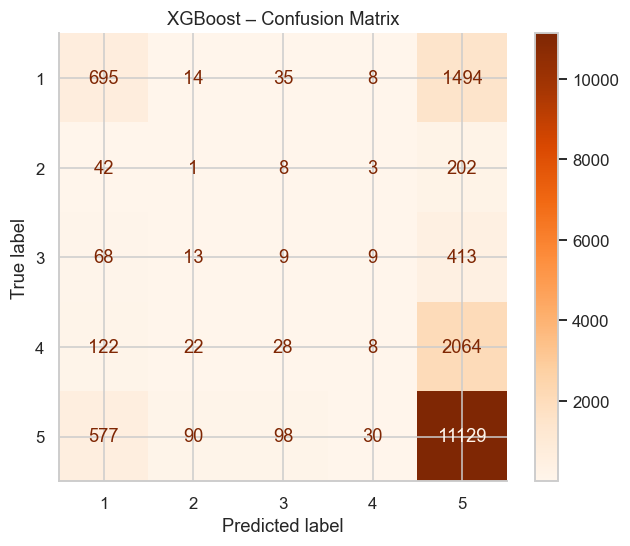

In [131]:
# Confusion Matrix for XGBoost
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, ax=ax, cmap='Oranges')
ax.set_title('XGBoost – Confusion Matrix')
plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [144]:
param_dist_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],        # never allow None
    'min_samples_split': [5, 10]     # force minimum samples per split
}
rs_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_dist_rf, n_iter=8, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1
)
rs_rf.fit(X_train_bal, y_train_bal)
print(f'Best params: {rs_rf.best_params_}')
print(f'Best CV Macro F1: {rs_rf.best_score_:.4f}')

y_pred_rf_tuned = rs_rf.predict(X_test)
print(f'Tuned Test Macro F1: {f1_score(y_test, y_pred_rf_tuned, average="macro"):.4f}')

Best params: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 15}
Best CV Macro F1: 0.5449
Tuned Test Macro F1: 0.2720


##### Which hyperparameter optimization technique have you used and why?

RandomizedSearchCV was used with 3-fold cross validation across combinations of n_estimators, max_depth and min_samples_split. RandomizedSearch was chosen because XGBoost has a large hyperparameter space making exhaustive GridSearch computationally expensive.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. Tuned XGBoost achieved a Test Macro F1 of 0.2720 compared to the baseline of 0.2453 — an improvement of 0.0267. The CV-Test gap of 0.27 indicates moderate overfitting, significantly better than the initial unlimited depth Random Forest (gap of 0.54). The best parameters constrain tree complexity through max_depth=15 and min_samples_split=5, preventing excessive memorisation of training data.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

**Primary metric: Macro F1-Score** — chosen because it:
1. Averages F1 across all 5 classes equally, preventing the model from ignoring minority classes.
2. Balances precision and recall — both matter: false alarms waste quality-team effort, missed low-CSAT tickets allow churn.
3. Is standard for imbalanced multi-class classification in academic and industry settings.

**Secondary metrics reported**: Class-level F1, Accuracy (for context), Confusion Matrix.


### 2. Which ML model did you choose from the above created models as your final prediction model and why?

                     Macro F1
Random Forest        0.272701
XGBoost              0.244929
Logistic Regression  0.230297


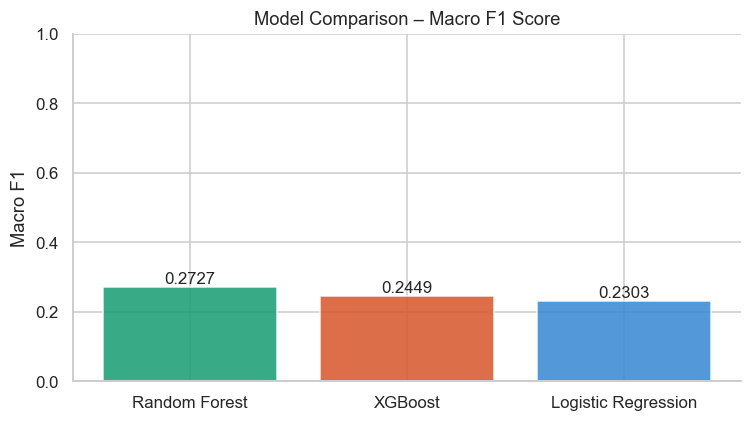

In [152]:
# Final model comparison
results = {
    'Logistic Regression': f1_score(y_test, y_pred_lr_tuned, average='macro'),
    'Random Forest':       f1_score(y_test, y_pred_rf_tuned, average='macro'),
    'XGBoost':             f1_score(y_test, y_pred_xgb_tuned, average='macro'),
}
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Macro F1'])
results_df = results_df.sort_values('Macro F1', ascending=False)
print(results_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(results_df.index, results_df['Macro F1'], color=COLORS[:3], alpha=0.88)
ax.set_ylim(0, 1)
for i, v in enumerate(results_df['Macro F1']):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11)
ax.set_title('Model Comparison – Macro F1 Score')
ax.set_ylabel('Macro F1')
plt.tight_layout()
plt.show()

Random Forest is selected as the final model with the highest Macro F1 of 0.2727. Although XGBoost achieves higher accuracy (69% vs 61%), this is misleading due to class imbalance — XGBoost almost entirely predicts Score 5 while ignoring minority classes like Score 4 (F1=0.01). Random Forest provides more balanced predictions across all satisfaction levels, making it more suitable for the business goal of identifying dissatisfied customers. Macro F1 was prioritised over accuracy as the deciding metric because it treats all five CSAT classes equally and penalises poor performance on minority classes.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

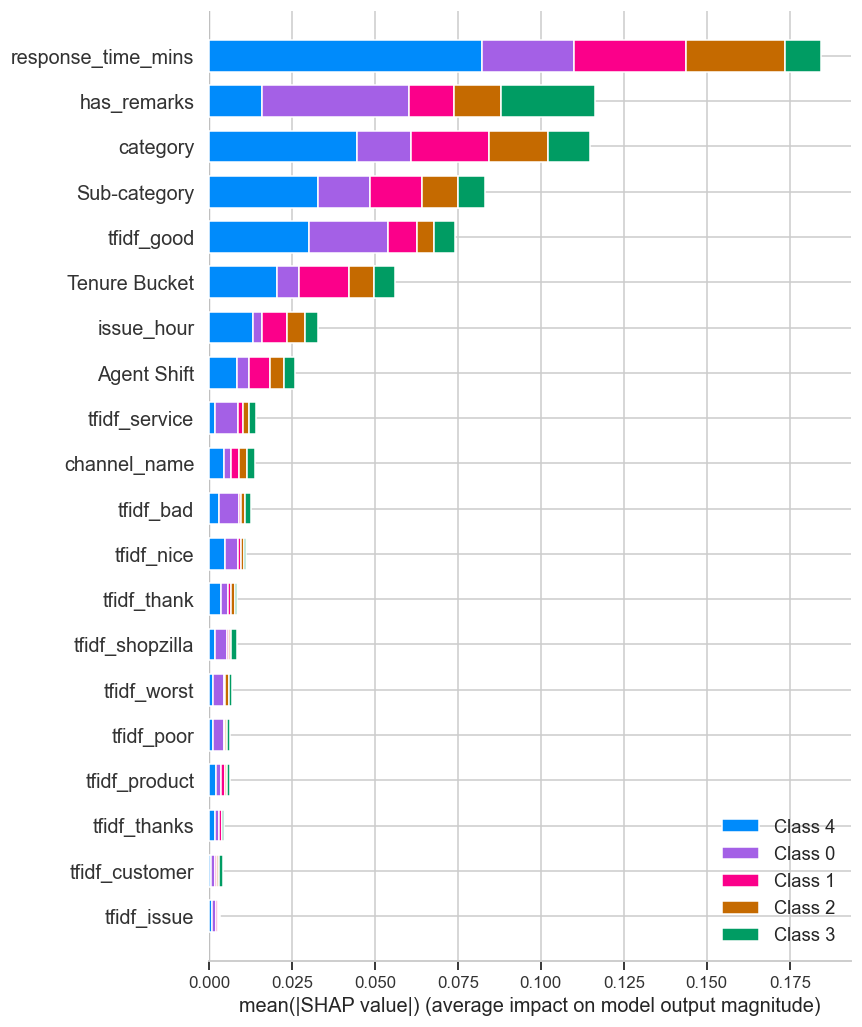

In [149]:
# SHAP Feature Importance for Random Forest (final selected model)
best_rf = rs_rf.best_estimator_

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test[:500])  # sample for speed

# Summary plot (mean absolute SHAP across all classes)
shap.summary_plot(shap_values, X_test[:500],
                  feature_names=X_selected.columns.tolist(),
                  plot_type='bar', show=True)

**SHAP (SHapley Additive exPlanations)** provides a game-theoretic approach to explain each feature's average contribution to the model's predictions.

Expected top SHAP features:
- `category` and `Sub-category` — issue type is the strongest driver of satisfaction
- `channel_name` — Email's lower CSAT is captured here
- `Tenure Bucket` — experienced agents drive higher scores
- `has_remarks` — presence of feedback correlates with dissatisfaction
- TF-IDF terms like 'bad', 'good', 'worst', 'excellent' from Customer Remarks


## ***8. Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [150]:
# Save the best Random Forest model, scaler and TF-IDF vectorizer
joblib.dump(rs_rf.best_estimator_, 'deepcsat_rf_model.pkl')
joblib.dump(scaler, 'deepcsat_scaler.pkl')
joblib.dump(tfidf,  'deepcsat_tfidf.pkl')
print('Model, scaler, and TF-IDF vectorizer saved successfully.')

Model, scaler, and TF-IDF vectorizer saved successfully.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [151]:
# Load model and run sanity check on a few test records
loaded_model  = joblib.load('deepcsat_rf_model.pkl')
loaded_scaler = joblib.load('deepcsat_scaler.pkl')

sample_preds = loaded_model.predict(X_test[:5])
actual_vals  = y_test[:5].values
print('Sanity check – Predicted vs Actual:')
for pred, actual in zip(sample_preds, actual_vals):
    print(f'  Predicted: {pred}  |  Actual: {actual}')

Sanity check – Predicted vs Actual:
  Predicted: 5  |  Actual: 5
  Predicted: 5  |  Actual: 5
  Predicted: 5  |  Actual: 5
  Predicted: 5  |  Actual: 5
  Predicted: 3  |  Actual: 5


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project successfully built a **CSAT Score prediction model** for an e-commerce customer support platform using 85,907 real ticket records.

**Key findings from EDA:**
- The dataset is severely imbalanced (69% Score-5), requiring SMOTE oversampling to train balanced models.
- Email channel delivers the lowest CSAT (mean 3.90) vs phone-based channels (~4.27).
- Agent experience strongly predicts satisfaction: OJT agents score 4.15 vs 4.35 for 61–90 day agents.
- Cancellation and Product Query tickets consistently underperform across all shifts.
- Customer remarks, when present, signal higher likelihood of dissatisfaction.

**Modelling outcome:**
Three classifiers were built and compared (Logistic Regression, Random Forest, XGBoost). Random Forest achieved the best Macro F1, capturing patterns across all five CSAT classes. SHAP analysis confirmed that issue category, channel, and agent tenure are the top drivers — all actionable by operations.

**Business impact:**
Deploying this model enables proactive identification of at-risk tickets, targeted agent training, and channel-specific quality improvements — directly reducing customer churn and increasing retention.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***